# Constrained Carreau-Yasuda Models

Fit the constrained Carreau-Yasuda model to slurry viscosity measurements using fixed $a=2.0$ and $\eta_\infty=0.01$, then build a row-level physics dataset.

## 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd

from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb

warnings.filterwarnings("ignore")

## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/combined_slurry_data_expanded.csv')

print(f"Rows: {len(df)}  |  Unique formulations (Composite_Mix_ID): {df['Composite_Mix_ID'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Rows: 178  |  Unique formulations (Composite_Mix_ID): 68
Columns: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s', 'Source_Batch', 'Composite_Mix_ID', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,Viscosity_at_shear_rate_1_1/s,Viscosity_at_shear_rate_10_1/s,Viscosity_at_shear_rate_100_1/s,Source_Batch,Composite_Mix_ID,NMC_pct,C65_pct,KS6L_pct,PVDF_pct
0,Hypermer,73.0,0.50,10.56640,3.78921,1.99755,Batch_1,F1_Hypermer_73.0_0.5,96.0,2.0,0.0,2.0
1,Hypermer,73.0,0.25,71.65190,14.08460,4.82515,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
2,Hypermer,73.0,0.25,9.64639,3.26827,1.61720,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0
3,Hypermer,77.0,0.25,61.11070,18.77450,7.51220,Batch_1,F1_Hypermer_77.0_0.25,96.0,2.0,0.0,2.0
4,Hypermer,73.0,0.25,8.37111,4.83186,2.30422,Batch_1,F1_Hypermer_73.0_0.25,96.0,2.0,0.0,2.0


## 3. Define the Constrained CY Model

In [3]:
def carreau_yasuda(shear_rate, eta_0, eta_inf, lambda_time, n, a):
    """Carreau-Yasuda viscosity model."""
    return eta_inf + (eta_0 - eta_inf) * (1.0 + (lambda_time * shear_rate) ** a) ** ((n - 1.0) / a)

shear_rates = np.array([1.0, 10.0, 100.0], dtype=float)
target_cols = [
    'Viscosity_at_shear_rate_1_1/s',
    'Viscosity_at_shear_rate_10_1/s',
    'Viscosity_at_shear_rate_100_1/s',
]

eps = 1e-8
df['Solid_to_Liquid_Ratio'] = df['Solid_Content_pct'] / (100.0 - df['Solid_Content_pct'] + eps)
df['Binder_to_Active_Ratio'] = df['PVDF_pct'] / (df['NMC_pct'] + df['C65_pct'] + eps)

input_cols = [
    'Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct',
    'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch',
    'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio',
]

print('Target columns:', target_cols)
print('Input columns :', input_cols)
display(df[input_cols + ['Composite_Mix_ID']].head())

Target columns: ['Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s']
Input columns : ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'NMC_pct', 'C65_pct', 'KS6L_pct', 'PVDF_pct', 'Source_Batch', 'Solid_to_Liquid_Ratio', 'Binder_to_Active_Ratio']


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio,Composite_Mix_ID
0,Hypermer,73.0,0.50,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.5
1,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25
2,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25
3,Hypermer,77.0,0.25,96.0,2.0,0.0,2.0,Batch_1,3.347826,0.020408,F1_Hypermer_77.0_0.25
4,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,F1_Hypermer_73.0_0.25


## 4. Fit the Constrained CY Model

In [4]:
USE_LOG_RESIDUALS = True
FIT_LOG_LAMBDA = True
LOG_LAMBDA_BOUNDS = (-3.0, 3.0)
LOCKED_ETA_INF = 0.01
LOCKED_A = 2.0
RESIDUAL_EPS = 1e-8
REG_WEIGHT = 1e-2

cy_dataset = []
failed_fits = []

def fit_row_cy_model(x_values, y_values, initial_guess_free, bounds_free, reg_weight=REG_WEIGHT):
    def residuals(theta_free):
        eta_0 = theta_free[0]
        if FIT_LOG_LAMBDA:
            lambda_time = np.exp(theta_free[1])
            n = theta_free[2]
        else:
            lambda_time = theta_free[1]
            n = theta_free[2]

        y_hat = carreau_yasuda(x_values, eta_0, LOCKED_ETA_INF, lambda_time, n, LOCKED_A)

        if USE_LOG_RESIDUALS:
            data_resid = np.log(y_values + RESIDUAL_EPS) - np.log(y_hat + RESIDUAL_EPS)
        else:
            data_resid = y_values - y_hat

        reg_resid = np.sqrt(reg_weight) * (theta_free - initial_guess_free)
        return np.concatenate([data_resid, reg_resid])

    return least_squares(residuals, x0=initial_guess_free, bounds=bounds_free, max_nfev=20000)

print('Constrained CY fit mode: locked a=2.0, eta_inf=0.01')
print(f'Log residuals: {USE_LOG_RESIDUALS} | Fit log(lambda): {FIT_LOG_LAMBDA} | log(lambda) bounds: {LOG_LAMBDA_BOUNDS}')
print(f'Fitting CY parameters for {len(df)} rows (entire dataset)...\n')

for row_idx, raw_row in df.iterrows():
    x_data = shear_rates.astype(float)
    y_data = raw_row[target_cols].values.astype(float)

    try:
        if FIT_LOG_LAMBDA:
            initial_guess_free = np.array([np.max(y_data), np.log(1.0), 0.5], dtype=float)
            bounds_free = (
                np.array([0.1, LOG_LAMBDA_BOUNDS[0], 0.1], dtype=float),
                np.array([np.inf, LOG_LAMBDA_BOUNDS[1], 1.0], dtype=float),
            )
        else:
            initial_guess_free = np.array([np.max(y_data), 1.0, 0.5], dtype=float)
            bounds_free = (
                np.array([0.1, 0.001, 0.1], dtype=float),
                np.array([np.inf, 100.0, 1.0], dtype=float),
            )

        final_fit = fit_row_cy_model(x_data, y_data, initial_guess_free, bounds_free)
        eta_0 = final_fit.x[0]
        lambda_time = np.exp(final_fit.x[1]) if FIT_LOG_LAMBDA else final_fit.x[1]
        n = final_fit.x[2]
        eta_inf = LOCKED_ETA_INF
        a = LOCKED_A

        y_pred_all = carreau_yasuda(x_data, eta_0, eta_inf, lambda_time, n, a)
        n_rmse = np.sqrt(np.mean((y_data - y_pred_all) ** 2))
        n_r2 = r2_score(y_data, y_pred_all)
        n_mae = np.mean(np.abs(y_data - y_pred_all))

        record = raw_row[input_cols].to_dict()
        record['row_index'] = row_idx
        record['Composite_Mix_ID'] = raw_row['Composite_Mix_ID']
        record['eta_0'] = eta_0
        record['eta_inf'] = eta_inf
        record['lambda_time'] = lambda_time
        record['n'] = n
        record['a'] = a
        record['CY_N_RMSE'] = n_rmse
        record['CY_N_R2'] = n_r2
        record['CY_N_MAE'] = n_mae

        cy_dataset.append(record)
    except Exception:
        failed_fits.append(row_idx)

print(f'Successful fits : {len(cy_dataset)}')
print(f'Failed fits     : {len(failed_fits)}' + (f'  -> first failed rows: {failed_fits[:10]}' if failed_fits else ''))

Constrained CY fit mode: locked a=2.0, eta_inf=0.01
Log residuals: True | Fit log(lambda): True | log(lambda) bounds: (-3.0, 3.0)
Fitting CY parameters for 178 rows (entire dataset)...

Successful fits : 178
Failed fits     : 0


## 5. Build Physics Dataset

In [5]:
physics_df = pd.DataFrame(cy_dataset)
physics_df['lambda_confidence'] = 1.0 / (physics_df['CY_N_RMSE'] + 1e-6)

print(f'Physics dataset shape: {physics_df.shape}')
print(f"Unique formulations: {physics_df['Composite_Mix_ID'].nunique()}")
print('\nCY parameter and n-sample fit summary:')
display(physics_df[['eta_0', 'eta_inf', 'lambda_time', 'n', 'a', 'CY_N_RMSE', 'CY_N_R2', 'CY_N_MAE']].describe().round(4))

print('\nPhysics dataset preview:')
display(physics_df.head())

Physics dataset shape: (178, 21)
Unique formulations: 68

CY parameter and n-sample fit summary:


,eta_0,eta_inf,lambda_time,n,a,CY_N_RMSE,CY_N_R2,CY_N_MAE
count,178.0000,178.00,178.0000,178.0000,178.0,178.0000,178.0000,178.0000
mean,53.0869,0.01,0.9922,0.5697,2.0,5.7604,0.9527,3.9999
std,66.1017,0.00,0.2129,0.1765,0.0,8.4983,0.0372,5.7102
min,1.1651,0.01,0.3865,0.1000,2.0,0.0081,0.8392,0.0075
25%,6.1971,0.01,0.8697,0.4211,2.0,0.1761,0.9235,0.1343
50%,23.9585,0.01,0.9931,0.5869,2.0,1.8866,0.9573,1.4675
75%,72.6663,0.01,1.1153,0.6963,2.0,8.4548,0.9881,5.9139
max,324.7339,0.01,1.5675,0.9133,2.0,43.9271,0.9998,29.1942



Physics dataset preview:


,Dispersent_Type,Solid_Content_pct,Solid_Additive_pct,NMC_pct,C65_pct,KS6L_pct,PVDF_pct,Source_Batch,Solid_to_Liquid_Ratio,Binder_to_Active_Ratio,...,Composite_Mix_ID,eta_0,eta_inf,lambda_time,n,a,CY_N_RMSE,CY_N_R2,CY_N_MAE,lambda_confidence
0,Hypermer,73.0,0.50,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,F1_Hypermer_73.0_0.5,10.983380,0.01,1.201290,0.629852,2.0,0.803254,0.952622,0.655236,1.244935
1,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,F1_Hypermer_73.0_0.25,71.794475,0.01,1.066575,0.402265,2.0,8.556573,0.916225,6.056591,0.116869
2,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,F1_Hypermer_73.0_0.25,10.116113,0.01,1.192704,0.602138,2.0,0.733608,0.955099,0.588815,1.363124
3,Hypermer,77.0,0.25,96.0,2.0,0.0,2.0,Batch_1,3.347826,0.020408,...,F1_Hypermer_77.0_0.25,61.238678,0.01,0.946289,0.527904,2.0,5.071627,0.951692,3.726268,0.197175
4,Hypermer,73.0,0.25,96.0,2.0,0.0,2.0,Batch_1,2.703704,0.020408,...,F1_Hypermer_73.0_0.25,8.687730,0.01,0.665396,0.684670,2.0,0.105779,0.998193,0.083599,9.453627


## 6. Quick Fit Summary

In [9]:
summary_stats = physics_df[[
    'CY_N_RMSE',
    'CY_N_R2',
    'CY_N_MAE',
]].agg(['mean', 'std', 'median']).round(4)

print('Summary of constrained CY fit accuracy (entire dataset):')
display(summary_stats)

print(f"Mean n-sample R2   : {physics_df['CY_N_R2'].mean():.4f}")
print(f"Mean n-sample RMSE : {physics_df['CY_N_RMSE'].mean():.4f}")
print(f"Mean n-sample MAE  : {physics_df['CY_N_MAE'].mean():.4f}")

Summary of constrained CY fit accuracy (entire dataset):


,CY_N_RMSE,CY_N_R2,CY_N_MAE
mean,5.7604,0.9527,3.9999
std,8.4983,0.0372,5.7102
median,1.8866,0.9573,1.4675


Mean n-sample R2   : 0.9527
Mean n-sample RMSE : 5.7604
Mean n-sample MAE  : 3.9999


## 7. Train-Test Split for ML Modeling

In [6]:
unique_formulations = physics_df['Composite_Mix_ID'].dropna().unique()
form_train, form_test = train_test_split(
    unique_formulations,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

physics_train = physics_df[physics_df['Composite_Mix_ID'].isin(form_train)].copy()
physics_test = physics_df[physics_df['Composite_Mix_ID'].isin(form_test)].copy()

print(f"Train set: {len(physics_train)} rows  |  {physics_train['Composite_Mix_ID'].nunique()} formulations")
print(f"Test set : {len(physics_test)} rows  |  {physics_test['Composite_Mix_ID'].nunique()} formulations")
print('No formulation leakage detected.' if set(physics_train['Composite_Mix_ID'].unique()).isdisjoint(set(physics_test['Composite_Mix_ID'].unique())) else 'Formulation leakage detected.')

Train set: 136 rows  |  54 formulations
Test set : 42 rows  |  14 formulations
No formulation leakage detected.


## 8. Simple Constrained CY Plot

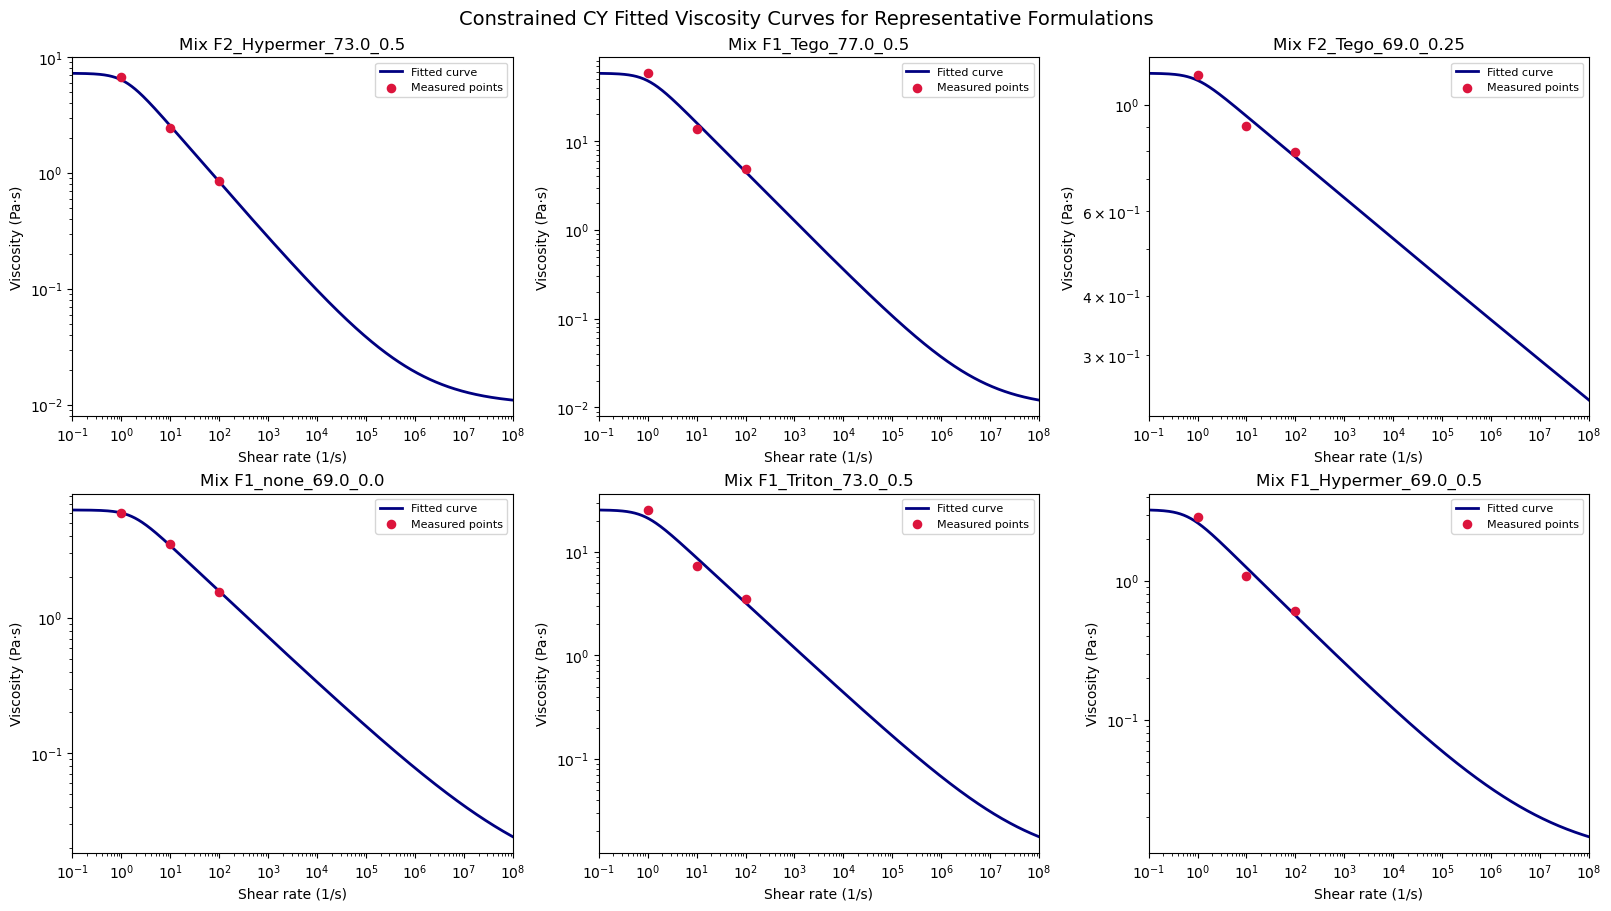

Representative fitted-curve quality:


,Composite_Mix_ID,CY_N_RMSE,CY_N_R2,CY_N_MAE
19,F2_Hypermer_73.0_0.5,0.2302,0.9914,0.1633
45,F1_Tego_77.0_0.5,6.0197,0.9333,4.3111
140,F2_Tego_69.0_0.25,0.0326,0.9528,0.0307
30,F1_none_69.0_0.0,0.0563,0.9990,0.0432
67,F1_Triton_73.0_0.5,2.4479,0.9332,1.8924
16,F1_Hypermer_69.0_0.5,0.1750,0.9678,0.1530


In [11]:
import matplotlib.pyplot as plt

plot_rows = physics_df.sample(n=min(6, len(physics_df)), random_state=42).copy()
shear_grid = np.logspace(-1, 8, 500)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, plot_rows.iterrows()):
    curve = carreau_yasuda(shear_grid, row['eta_0'], row['eta_inf'], row['lambda_time'], row['n'], row['a'])
    measured = df.loc[row['row_index'], target_cols].values.astype(float)

    ax.plot(shear_grid, curve, color='navy', linewidth=2, label='Fitted curve')
    ax.scatter(shear_rates, measured, color='crimson', s=35, zorder=3, label='Measured points')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(shear_grid.min(), shear_grid.max())
    ax.set_xlabel('Shear rate (1/s)')
    ax.set_ylabel('Viscosity (Pa·s)')
    ax.set_title(f"Mix {row['Composite_Mix_ID']}")
    ax.legend(fontsize=8)

for ax in axes[len(plot_rows):]:
    ax.axis('off')

plt.suptitle('Constrained CY Fitted Viscosity Curves for Representative Formulations', fontsize=14)
plt.show()

curve_quality = plot_rows[['Composite_Mix_ID', 'CY_N_RMSE', 'CY_N_R2', 'CY_N_MAE']].copy()
print('Representative fitted-curve quality:')
display(curve_quality.round(4))

## 9. GPR for Constrained CY Parameters

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, RationalQuadratic, ExpSineSquared, DotProduct
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

feature_cols = input_cols.copy()
gpr_targets = ['eta_0', 'lambda_time', 'n']

X_train = physics_train[feature_cols].copy()
X_test = physics_test[feature_cols].copy()

X_train = pd.get_dummies(X_train, columns=['Dispersent_Type', 'Source_Batch'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Dispersent_Type', 'Source_Batch'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

gpr_models = {}
gpr_results = []

for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)

    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train

    kernel = (
        RBF(length_scale=np.ones(X_train_scaled.shape[1]), length_scale_bounds=(1e-2, 1e3))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        random_state=42,
        n_restarts_optimizer=3,
    )
    gpr.fit(X_train_scaled, y_train_fit)

    y_train_pred_fit = gpr.predict(X_train_scaled)
    y_test_pred_fit = gpr.predict(X_test_scaled)

    if use_log_target:
        y_train_pred = np.exp(y_train_pred_fit)
        y_test_pred = np.exp(y_test_pred_fit)
    else:
        y_train_pred = y_train_pred_fit
        y_test_pred = y_test_pred_fit

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    gpr_models[target] = gpr
    gpr_results.append({
        'target': target,
        'log_target': use_log_target,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'kernel': str(gpr.kernel_),
    })

gpr_results_df = pd.DataFrame(gpr_results).sort_values('target').reset_index(drop=True)
mean_train_r2 = gpr_results_df['train_r2'].mean()
mean_test_r2 = gpr_results_df['test_r2'].mean()

print('GPR results for constrained CY parameters (RBF + White kernel):')
display(gpr_results_df.round(4))
print(f'Mean Train R2 across targets: {mean_train_r2:.4f}')
print(f'Mean Test R2 across targets : {mean_test_r2:.4f}')

GPR results for constrained CY parameters (RBF + White kernel):


,target,log_target,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae,kernel
0,eta_0,True,0.7497,0.6739,32.9497,37.7533,18.8229,21.7117,"RBF(length_scale=[1.94, 5.39, 1.01, 1, 0.999, ..."
1,lambda_time,True,0.6072,-0.0412,0.1342,0.2078,0.1054,0.1567,"RBF(length_scale=[1.33, 1.41, 1, 1, 1, 1, 1e+0..."
2,n,False,0.6337,0.5645,0.1048,0.1221,0.0791,0.0930,"RBF(length_scale=[2.77, 5.98, 14.6, 1.95, 0.72..."


Mean Train R2 across targets: 0.6635
Mean Test R2 across targets : 0.3990


## 10. XGBoost for Constrained CY Parameters

In [8]:
xgb_models = {}
xgb_results = []

for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)

    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train

    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    xgb_model.fit(X_train_scaled, y_train_fit)

    y_train_pred_fit = xgb_model.predict(X_train_scaled)
    y_test_pred_fit = xgb_model.predict(X_test_scaled)

    if use_log_target:
        y_train_pred = np.exp(y_train_pred_fit)
        y_test_pred = np.exp(y_test_pred_fit)
    else:
        y_train_pred = y_train_pred_fit
        y_test_pred = y_test_pred_fit

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    xgb_models[target] = xgb_model
    xgb_results.append({
        'target': target,
        'log_target': use_log_target,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
    })

xgb_results_df = pd.DataFrame(xgb_results).sort_values('target').reset_index(drop=True)
mean_train_r2_xgb = xgb_results_df['train_r2'].mean()
mean_test_r2_xgb = xgb_results_df['test_r2'].mean()

print('XGBoost results for constrained CY parameters:')
display(xgb_results_df.round(4))
print(f'Mean Train R2 across targets: {mean_train_r2_xgb:.4f}')
print(f'Mean Test R2 across targets : {mean_test_r2_xgb:.4f}')

# Comparison table: GPR vs XGBoost
print('\n\n=== GPR vs XGBoost Comparison ===\n')
comparison_data = []
for target in gpr_targets:
    gpr_row = gpr_results_df[gpr_results_df['target'] == target].iloc[0]
    xgb_row = xgb_results_df[xgb_results_df['target'] == target].iloc[0]
    
    comparison_data.append({
        'target': target,
        'GPR_train_r2': gpr_row['train_r2'],
        'XGB_train_r2': xgb_row['train_r2'],
        'GPR_test_r2': gpr_row['test_r2'],
        'XGB_test_r2': xgb_row['test_r2'],
        'GPR_test_rmse': gpr_row['test_rmse'],
        'XGB_test_rmse': xgb_row['test_rmse'],
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

# Overall summary
print(f'\n--- Overall Summary ---')
print(f'GPR:    Mean Train R² = {mean_train_r2:.4f}, Mean Test R² = {mean_test_r2:.4f}')
print(f'XGBoost: Mean Train R² = {mean_train_r2_xgb:.4f}, Mean Test R² = {mean_test_r2_xgb:.4f}')

XGBoost results for constrained CY parameters:


,target,log_target,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,eta_0,True,0.8057,0.6931,29.0254,36.6226,15.4070,23.1438
1,lambda_time,True,0.6840,-0.2945,0.1203,0.2316,0.0877,0.1804
2,n,False,0.7965,0.3778,0.0781,0.1459,0.0511,0.1078


Mean Train R2 across targets: 0.7621
Mean Test R2 across targets : 0.2588


=== GPR vs XGBoost Comparison ===



,target,GPR_train_r2,XGB_train_r2,GPR_test_r2,XGB_test_r2,GPR_test_rmse,XGB_test_rmse
0,eta_0,0.7497,0.8057,0.6739,0.6931,37.7533,36.6226
1,lambda_time,0.6072,0.6840,-0.0412,-0.2945,0.2078,0.2316
2,n,0.6337,0.7965,0.5645,0.3778,0.1221,0.1459



--- Overall Summary ---
GPR:    Mean Train R² = 0.6635, Mean Test R² = 0.3990
XGBoost: Mean Train R² = 0.7621, Mean Test R² = 0.2588


## 11. GPR with Matern 2.5 Kernel

In [9]:
matern_models = {}
matern_results = []

for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)

    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train

    kernel = (
        Matern(nu=2.5, length_scale=np.ones(X_train_scaled.shape[1]), length_scale_bounds=(1e-2, 1e3))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        random_state=42,
        n_restarts_optimizer=3,
    )
    gpr.fit(X_train_scaled, y_train_fit)

    y_train_pred_fit = gpr.predict(X_train_scaled)
    y_test_pred_fit = gpr.predict(X_test_scaled)

    if use_log_target:
        y_train_pred = np.exp(y_train_pred_fit)
        y_test_pred = np.exp(y_test_pred_fit)
    else:
        y_train_pred = y_train_pred_fit
        y_test_pred = y_test_pred_fit

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    matern_models[target] = gpr
    matern_results.append({
        'target': target,
        'log_target': use_log_target,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
    })

matern_results_df = pd.DataFrame(matern_results).sort_values('target').reset_index(drop=True)
mean_train_r2_matern = matern_results_df['train_r2'].mean()
mean_test_r2_matern = matern_results_df['test_r2'].mean()

print('GPR results with Matern 2.5 kernel:')
display(matern_results_df.round(4))
print(f'Mean Train R2 across targets: {mean_train_r2_matern:.4f}')
print(f'Mean Test R2 across targets : {mean_test_r2_matern:.4f}')

# Three-way comparison: RBF+White, Matern 2.5, XGBoost
print('\n\n=== All Models Comparison (GPR RBF+White vs Matern 2.5 vs XGBoost) ===\n')
all_comparison = []
for target in gpr_targets:
    gpr_row = gpr_results_df[gpr_results_df['target'] == target].iloc[0]
    matern_row = matern_results_df[matern_results_df['target'] == target].iloc[0]
    xgb_row = xgb_results_df[xgb_results_df['target'] == target].iloc[0]
    
    all_comparison.append({
        'target': target,
        'RBF_test_r2': gpr_row['test_r2'],
        'Matern25_test_r2': matern_row['test_r2'],
        'XGB_test_r2': xgb_row['test_r2'],
        'RBF_train_r2': gpr_row['train_r2'],
        'Matern25_train_r2': matern_row['train_r2'],
        'XGB_train_r2': xgb_row['train_r2'],
    })

all_comparison_df = pd.DataFrame(all_comparison)
display(all_comparison_df.round(4))

print(f'\n--- Overall Mean Test R² ---')
print(f'RBF + White:  {mean_test_r2:.4f}')
print(f'Matern 2.5:   {mean_test_r2_matern:.4f}')
print(f'XGBoost:      {mean_test_r2_xgb:.4f}')

GPR results with Matern 2.5 kernel:


,target,log_target,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,eta_0,True,0.7523,0.6583,32.7758,38.6423,18.4819,21.5823
1,lambda_time,True,0.6039,-0.0348,0.1347,0.2071,0.1060,0.1544
2,n,False,0.6655,0.5551,0.1001,0.1234,0.0756,0.0941


Mean Train R2 across targets: 0.6739
Mean Test R2 across targets : 0.3929


=== All Models Comparison (GPR RBF+White vs Matern 2.5 vs XGBoost) ===



,target,RBF_test_r2,Matern25_test_r2,XGB_test_r2,RBF_train_r2,Matern25_train_r2,XGB_train_r2
0,eta_0,0.6739,0.6583,0.6931,0.7497,0.7523,0.8057
1,lambda_time,-0.0412,-0.0348,-0.2945,0.6072,0.6039,0.6840
2,n,0.5645,0.5551,0.3778,0.6337,0.6655,0.7965



--- Overall Mean Test R² ---
RBF + White:  0.3990
Matern 2.5:   0.3929
XGBoost:      0.2588


## 12. Kernel Comparison: Matern 1.5, Matern ∞, RQ, ExpSineSquared, DotProduct

In [10]:
# Dictionary to store all kernel results
all_kernel_results = {}

# Test Matern 1.5
kernel_name = 'Matern15'
all_kernel_results[kernel_name] = []
for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)
    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train
    
    kernel = Matern(nu=1.5, length_scale=np.ones(X_train_scaled.shape[1]), length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42, n_restarts_optimizer=3)
    gpr.fit(X_train_scaled, y_train_fit)
    
    y_pred_train = np.exp(gpr.predict(X_train_scaled)) if use_log_target else gpr.predict(X_train_scaled)
    y_pred_test = np.exp(gpr.predict(X_test_scaled)) if use_log_target else gpr.predict(X_test_scaled)
    
    all_kernel_results[kernel_name].append({
        'target': target,
        'test_r2': r2_score(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
    })

# Test Matern ∞ (equivalent to RBF)
kernel_name = 'Matern_inf'
all_kernel_results[kernel_name] = []
for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)
    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train
    
    kernel = Matern(nu=np.inf, length_scale=np.ones(X_train_scaled.shape[1]), length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42, n_restarts_optimizer=3)
    gpr.fit(X_train_scaled, y_train_fit)
    
    y_pred_train = np.exp(gpr.predict(X_train_scaled)) if use_log_target else gpr.predict(X_train_scaled)
    y_pred_test = np.exp(gpr.predict(X_test_scaled)) if use_log_target else gpr.predict(X_test_scaled)
    
    all_kernel_results[kernel_name].append({
        'target': target,
        'test_r2': r2_score(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
    })

# Test Rational Quadratic
kernel_name = 'RationalQuadratic'
all_kernel_results[kernel_name] = []
for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)
    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train
    
    kernel = RationalQuadratic(length_scale=1.0, alpha=1.0, length_scale_bounds=(1e-2, 1e3), alpha_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42, n_restarts_optimizer=3)
    gpr.fit(X_train_scaled, y_train_fit)
    
    y_pred_train = np.exp(gpr.predict(X_train_scaled)) if use_log_target else gpr.predict(X_train_scaled)
    y_pred_test = np.exp(gpr.predict(X_test_scaled)) if use_log_target else gpr.predict(X_test_scaled)
    
    all_kernel_results[kernel_name].append({
        'target': target,
        'test_r2': r2_score(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
    })

# Test ExpSineSquared (periodic)
kernel_name = 'ExpSineSquared'
all_kernel_results[kernel_name] = []
for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)
    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train
    
    kernel = ExpSineSquared(length_scale=1.0, periodicity=1.0, length_scale_bounds=(1e-2, 1e3), periodicity_bounds=(0.1, 10)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42, n_restarts_optimizer=3)
    gpr.fit(X_train_scaled, y_train_fit)
    
    y_pred_train = np.exp(gpr.predict(X_train_scaled)) if use_log_target else gpr.predict(X_train_scaled)
    y_pred_test = np.exp(gpr.predict(X_test_scaled)) if use_log_target else gpr.predict(X_test_scaled)
    
    all_kernel_results[kernel_name].append({
        'target': target,
        'test_r2': r2_score(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
    })

# Test DotProduct
kernel_name = 'DotProduct'
all_kernel_results[kernel_name] = []
for target in gpr_targets:
    y_train = physics_train[target].values.astype(float)
    y_test = physics_test[target].values.astype(float)
    use_log_target = target in ['eta_0', 'lambda_time']
    y_train_fit = np.log(y_train + 1e-8) if use_log_target else y_train
    
    kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42, n_restarts_optimizer=3)
    gpr.fit(X_train_scaled, y_train_fit)
    
    y_pred_train = np.exp(gpr.predict(X_train_scaled)) if use_log_target else gpr.predict(X_train_scaled)
    y_pred_test = np.exp(gpr.predict(X_test_scaled)) if use_log_target else gpr.predict(X_test_scaled)
    
    all_kernel_results[kernel_name].append({
        'target': target,
        'test_r2': r2_score(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
    })

# Build comprehensive comparison table
print('=== Comprehensive Kernel Comparison (All targets, Mean Test R²) ===\n')
kernel_summary = {}
for kernel_name, results in all_kernel_results.items():
    df_results = pd.DataFrame(results)
    mean_test_r2 = df_results['test_r2'].mean()
    mean_train_r2 = df_results['train_r2'].mean()
    kernel_summary[kernel_name] = {'mean_test_r2': mean_test_r2, 'mean_train_r2': mean_train_r2}

# Also add previously computed results
kernel_summary['RBF_White'] = {'mean_test_r2': mean_test_r2, 'mean_train_r2': mean_train_r2}
kernel_summary['Matern25'] = {'mean_test_r2': mean_test_r2_matern, 'mean_train_r2': mean_train_r2_matern}
kernel_summary['XGBoost'] = {'mean_test_r2': mean_test_r2_xgb, 'mean_train_r2': mean_train_r2_xgb}

summary_df = pd.DataFrame(kernel_summary).T.sort_values('mean_test_r2', ascending=False)
display(summary_df.round(4))

print('\nRanking by Mean Test R²:')
for i, (kernel, row) in enumerate(summary_df.iterrows(), 1):
    print(f'{i}. {kernel:20s} | Test R²: {row["mean_test_r2"]:.4f} | Train R²: {row["mean_train_r2"]:.4f}')

=== Comprehensive Kernel Comparison (All targets, Mean Test R²) ===



,mean_test_r2,mean_train_r2
RationalQuadratic,0.4541,0.6684
Matern_inf,0.3965,0.6688
Matern25,0.3929,0.6739
Matern15,0.3835,0.6836
DotProduct,0.3765,0.4962
RBF_White,0.3765,0.4962
XGBoost,0.2588,0.7621
ExpSineSquared,-0.0979,0.3997



Ranking by Mean Test R²:
1. RationalQuadratic    | Test R²: 0.4541 | Train R²: 0.6684
2. Matern_inf           | Test R²: 0.3965 | Train R²: 0.6688
3. Matern25             | Test R²: 0.3929 | Train R²: 0.6739
4. Matern15             | Test R²: 0.3835 | Train R²: 0.6836
5. DotProduct           | Test R²: 0.3765 | Train R²: 0.4962
6. RBF_White            | Test R²: 0.3765 | Train R²: 0.4962
7. XGBoost              | Test R²: 0.2588 | Train R²: 0.7621
8. ExpSineSquared       | Test R²: -0.0979 | Train R²: 0.3997


## 13. Per-Target Results Across All Kernels

In [11]:
# Build per-target tables from all available model results
per_target_rows = []

# Baseline GPR (RBF + White)
for _, row in gpr_results_df.iterrows():
    per_target_rows.append({
        'model': 'RBF_White',
        'target': row['target'],
        'train_r2': row['train_r2'],
        'test_r2': row['test_r2'],
    })

# GPR with Matern 2.5
for _, row in matern_results_df.iterrows():
    per_target_rows.append({
        'model': 'Matern25',
        'target': row['target'],
        'train_r2': row['train_r2'],
        'test_r2': row['test_r2'],
    })

# XGBoost
for _, row in xgb_results_df.iterrows():
    per_target_rows.append({
        'model': 'XGBoost',
        'target': row['target'],
        'train_r2': row['train_r2'],
        'test_r2': row['test_r2'],
    })

# Additional kernels tested in the comprehensive comparison cell
for model_name, records in all_kernel_results.items():
    for record in records:
        per_target_rows.append({
            'model': model_name,
            'target': record['target'],
            'train_r2': record['train_r2'],
            'test_r2': record['test_r2'],
        })

per_target_df = pd.DataFrame(per_target_rows)

print('Per-target TEST R² across all models:')
test_pivot = per_target_df.pivot(index='model', columns='target', values='test_r2')
test_pivot['mean_test_r2'] = test_pivot.mean(axis=1)
display(test_pivot.sort_values('mean_test_r2', ascending=False).round(4))

print('Per-target TRAIN R² across all models:')
train_pivot = per_target_df.pivot(index='model', columns='target', values='train_r2')
train_pivot['mean_train_r2'] = train_pivot.mean(axis=1)
display(train_pivot.sort_values('mean_train_r2', ascending=False).round(4))

print('Best model by target (TEST R²):')
for t in ['eta_0', 'lambda_time', 'n']:
    best_row = test_pivot[t].idxmax()
    best_val = test_pivot[t].max()
    print(f'- {t}: {best_row} ({best_val:.4f})')

Per-target TEST R² across all models:


target,eta_0,lambda_time,n,mean_test_r2
model,,,,
RationalQuadratic,0.7023,0.1539,0.5060,0.4541
RBF_White,0.6739,-0.0412,0.5645,0.3990
Matern_inf,0.6739,-0.0412,0.5568,0.3965
Matern25,0.6583,-0.0348,0.5551,0.3929
Matern15,0.6443,-0.0501,0.5563,0.3835
DotProduct,0.6638,-0.0593,0.5249,0.3765
XGBoost,0.6931,-0.2945,0.3778,0.2588
ExpSineSquared,-0.1931,-0.0996,-0.0010,-0.0979


Per-target TRAIN R² across all models:


target,eta_0,lambda_time,n,mean_train_r2
model,,,,
XGBoost,0.8057,0.6840,0.7965,0.7621
Matern15,0.7568,0.6088,0.6853,0.6836
Matern25,0.7523,0.6039,0.6655,0.6739
Matern_inf,0.7497,0.6072,0.6496,0.6688
RationalQuadratic,0.7462,0.5928,0.6663,0.6684
RBF_White,0.7497,0.6072,0.6337,0.6635
DotProduct,0.7072,0.2089,0.5724,0.4962
ExpSineSquared,0.1325,0.2830,0.7837,0.3997


Best model by target (TEST R²):
- eta_0: RationalQuadratic (0.7023)
- lambda_time: RationalQuadratic (0.1539)
- n: RBF_White (0.5645)
